# **Health Monitoring and Analysis**

This project focuses on exploratory data analysis (EDA) of a health monitoring dataset containing demographic, physiological, and lifestyle-related information.

The analysis includes data cleaning, handling missing values, descriptive statistics, visualization, correlation analysis, and comparison of health indicators across different groups. The goal is to better understand the structure of the dataset and identify patterns and relationships between health metrics such as heart rate, blood pressure, respiratory rate, body temperature, and oxygen saturation. The timestamp variable was converted to datetime format so that the measurements could be ordered and analyzed over time

**Objective**

The objective of this project is to explore and understand health monitoring data by:

- cleaning and preparing the dataset,
- analyzing the distribution of key health metrics,
- examining relationships between numerical variables,
- comparing health indicators across demographic and lifestyle groups,
- and identifying relevant patterns through exploratory data analysis.

**Data Dictionary**
  

| Column Name       | Description                                                   | Turkish Translation                                  |
|-------------------|---------------------------------------------------------------|------------------------------------------------------|
| PatientID         | Unique numerical identifier for each patient                  | Hastaya ait benzersiz sayısal kimlik numarası       |
| Age               | Age of the patient in years                                   | Hastanın yaşı (yıl cinsinden)                        |
| Gender            | Gender of the patient                                         | Hastanın cinsiyeti                                   |
| HeartRate         | Heart rate in beats per minute (bpm)                          | Dakikadaki kalp atım sayısı (nabız)                  |
| BloodPressure     | Blood pressure in systolic/diastolic format (mmHg)            | Sistolik/diyastolik kan basıncı (mmHg)               |
| RespiratoryRate   | Respiratory rate in breaths per minute                        | Dakikadaki solunum sayısı (solunum hızı)             |
| BodyTemperature   | Body temperature in Fahrenheit                                | Fahrenheit cinsinden vücut sıcaklığı                 |
| ActivityLevel     | Activity level at the time of measurement                     | Ölçüm anındaki aktivite seviyesi                     |
| OxygenSaturation  | Blood oxygen saturation percentage                            | Kandaki oksijen satürasyonu yüzdesi                  |
| SleepQuality      | Quality of sleep reported by the patient                      | Hastanın bildirdiği uyku kalitesi                    |
| StressLevel       | Reported level of stress                                      | Bildirilen stres seviyesi                            |
| Timestamp         | Date and time of the measurement                              | Ölçümün tarihi ve saati                              |

<img src='https://mms.businesswire.com/media/20211021005727/en/918944/5/2021-10_Press_Image_Remote_Health_Monitoring.jpg' width='900'>
<a href='https://thecleverprogrammer.com/2024/04/29/health-monitoring-and-analysis-using-python/' target=_blank>
Click here for the dataset </a>

**Import libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Read the Data**

In [2]:
df = pd.read_csv('healthmonitoring.csv')
print(df.head())

   PatientID  Age  Gender  HeartRate BloodPressure  RespiratoryRate  \
0          1   69    Male  60.993428        130/85               15   
1          2   32    Male  98.723471        120/80               23   
2          3   78  Female  82.295377        130/85               13   
3          4   38  Female  80.000000        111/78               19   
4          5   41    Male  87.531693        120/80               14   

   BodyTemperature ActivityLevel  OxygenSaturation SleepQuality StressLevel  \
0        98.885236       resting              95.0    excellent         low   
1        98.281883       walking              97.0         good        high   
2        98.820286       resting              98.0         fair        high   
3        98.412594       running              98.0         poor    moderate   
4        99.369871       resting              98.0         good         low   

                    Timestamp  
0  2024-04-26 17:28:55.286711  
1  2024-04-26 17:23:55.286722  
2 

###
**EDA - Exploratory Data Analysis**

In [3]:
df.shape

(500, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PatientID         500 non-null    int64  
 1   Age               500 non-null    int64  
 2   Gender            500 non-null    str    
 3   HeartRate         500 non-null    float64
 4   BloodPressure     500 non-null    str    
 5   RespiratoryRate   500 non-null    int64  
 6   BodyTemperature   482 non-null    float64
 7   ActivityLevel     500 non-null    str    
 8   OxygenSaturation  337 non-null    float64
 9   SleepQuality      500 non-null    str    
 10  StressLevel       500 non-null    str    
 11  Timestamp         500 non-null    str    
dtypes: float64(3), int64(3), str(6)
memory usage: 73.5 KB


In [5]:
df.isnull().sum()

PatientID             0
Age                   0
Gender                0
HeartRate             0
BloodPressure         0
RespiratoryRate       0
BodyTemperature      18
ActivityLevel         0
OxygenSaturation    163
SleepQuality          0
StressLevel           0
Timestamp             0
dtype: int64

**Data Preparation**

In [ ]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [11]:
# Calculate median values
median_body_temp = df['BodyTemperature'].median()
median_oxygen_sat = df['OxygenSaturation'].median()

# Fill missing values
df['BodyTemperature'] = df['BodyTemperature'].fillna(median_body_temp)
df['OxygenSaturation'] = df['OxygenSaturation'].fillna(median_oxygen_sat)

# Validate that no missing values remain
assert df[['BodyTemperature', 'OxygenSaturation']].isna().sum().sum() == 0

**Data Visualization**

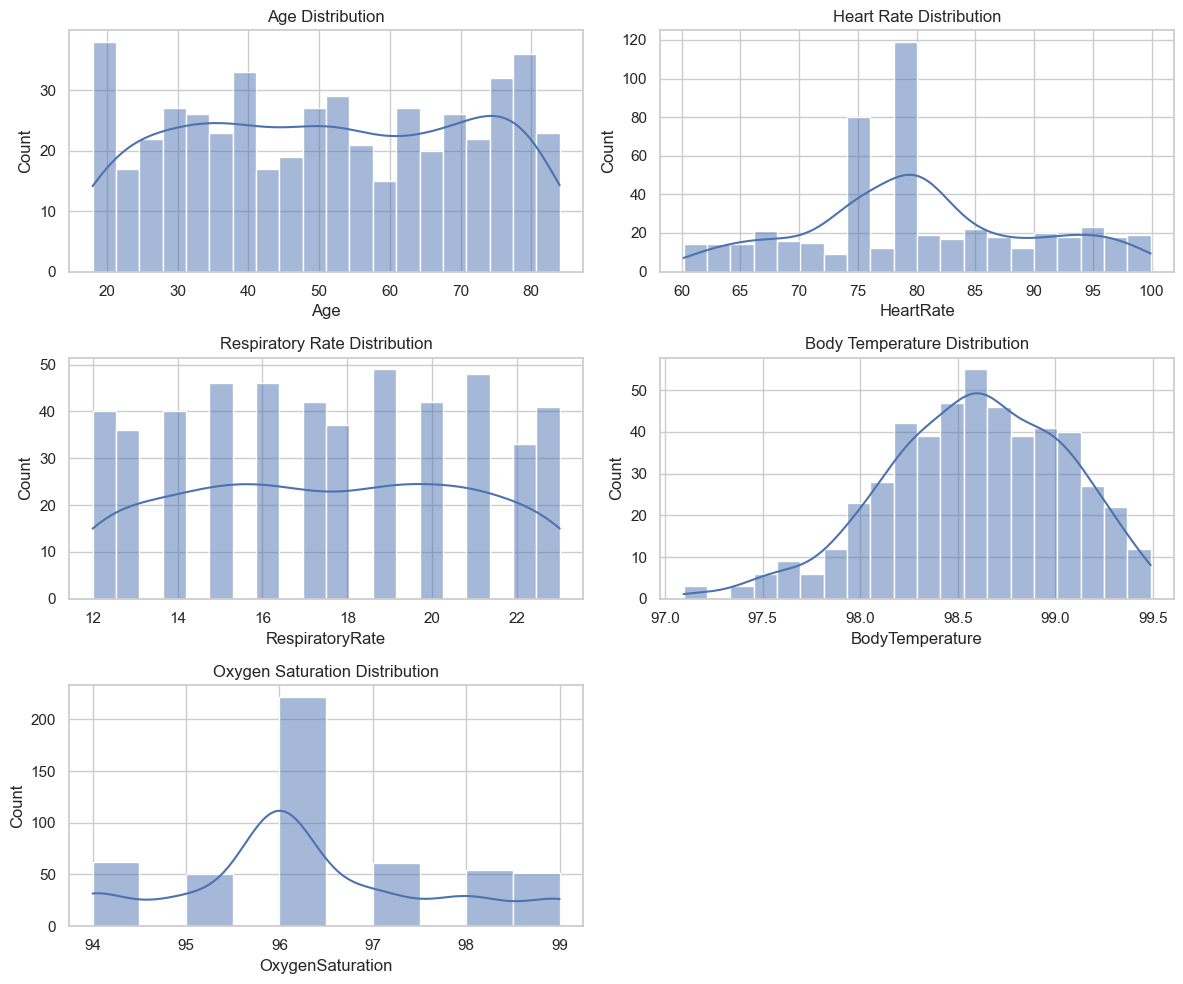

In [16]:
sns.set_theme(style="whitegrid")

# Plot distributions of numerical features
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['HeartRate'], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Heart Rate Distribution')

sns.histplot(df['RespiratoryRate'], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Respiratory Rate Distribution')

sns.histplot(df['BodyTemperature'], bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Body Temperature Distribution')

sns.histplot(df['OxygenSaturation'], bins=10, kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Oxygen Saturation Distribution')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

In [18]:
# Summary statistics of health metrics
health_metrics = [
    'Age',
    'HeartRate',
    'RespiratoryRate',
    'BodyTemperature',
    'OxygenSaturation'
]

summary_stats = df[health_metrics].describe().round(2)
summary_stats

,Age,HeartRate,RespiratoryRate,BodyTemperature,OxygenSaturation
count,500.00,500.00,500.00,500.00,500.00
mean,51.15,80.13,17.52,98.58,96.30
std,19.82,9.61,3.38,0.46,1.41
min,18.00,60.17,12.00,97.09,94.00
25%,34.00,75.00,15.00,98.28,96.00
50%,51.00,80.00,17.50,98.61,96.00
75%,69.00,86.28,20.00,98.93,97.00
max,84.00,99.93,23.00,99.49,99.00


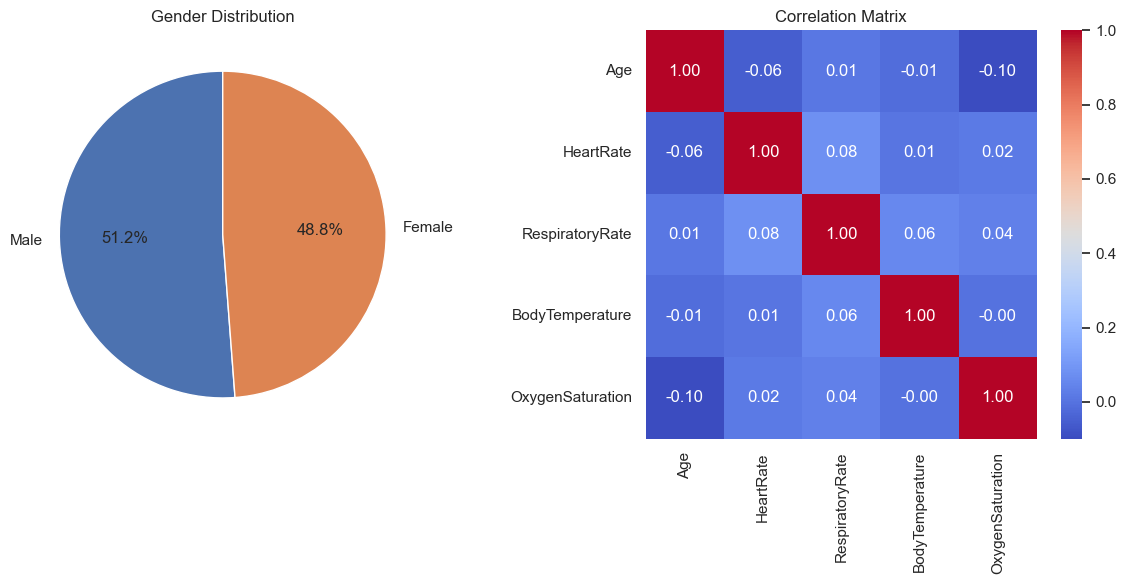

In [21]:
# Gender distribution
gender_counts = df['Gender'].value_counts()

# Correlation matrix
correlation_matrix = df[health_metrics].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

gender_counts.plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_ylabel('')
axes[0].set_title('Gender Distribution')

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

The gender distribution is nearly balanced, with 51.2% male and 48.8% female participants. The correlation matrix shows only very weak linear relationships between the numerical health metrics, as all correlation values are close to zero. No strong positive or negative correlations are observed in this dataset.

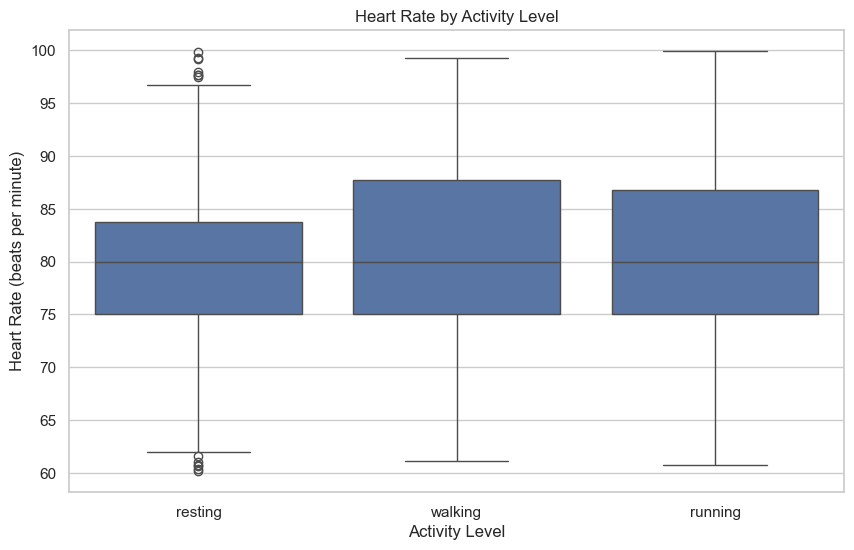

In [25]:
# Heart rate by activity level
plt.figure(figsize=(10, 6))
sns.boxplot(x='ActivityLevel', y='HeartRate', data=df)

plt.title('Heart Rate by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Heart Rate (beats per minute)')

plt.show()

Heart rate distributions are similar across resting, walking, and running activity levels. Only small differences are observed between the groups.

In [27]:
# Blood Pressure and Gender-Based Analysis

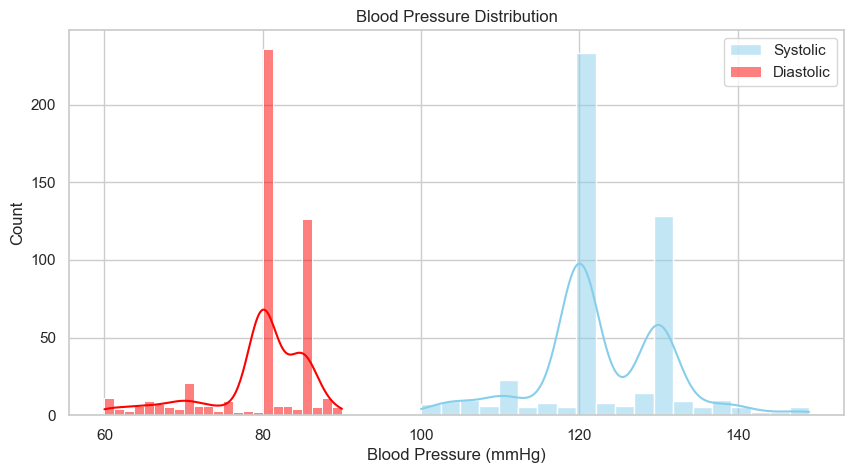

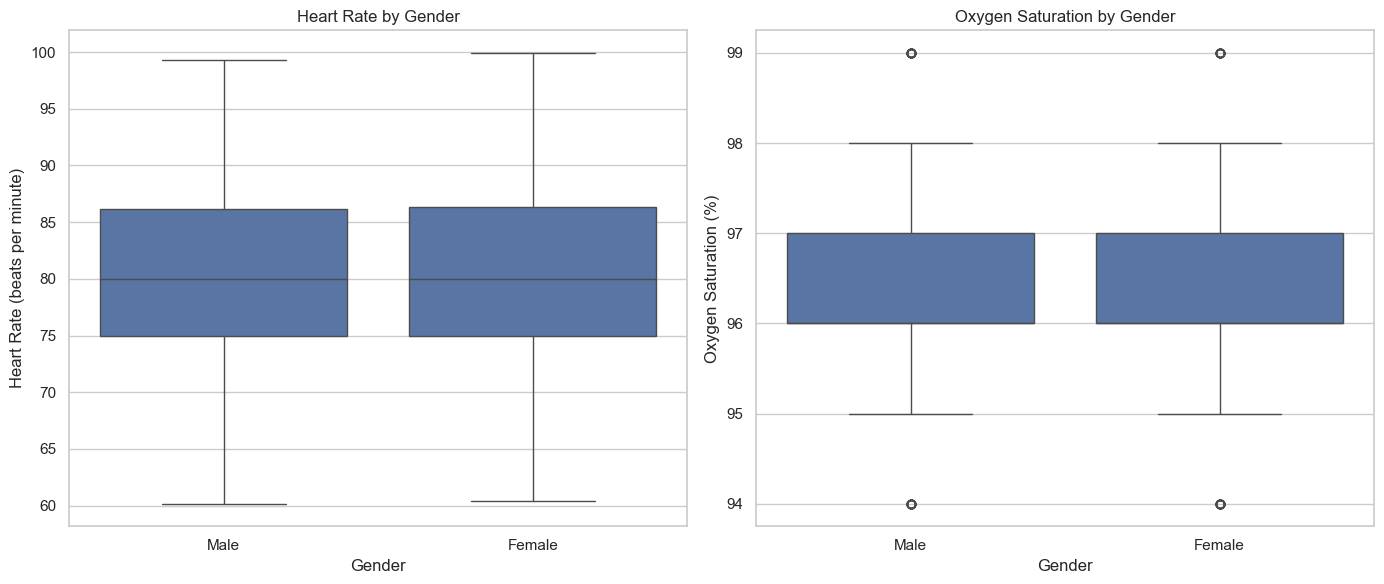

In [26]:
df[['SystolicBP', 'DiastolicBP']] = (
    df['BloodPressure']
    .str.split('/', expand=True)
    .astype(int)
)

# Blood pressure distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['SystolicBP'], color='skyblue', label='Systolic', kde=True)
sns.histplot(df['DiastolicBP'], color='red', label='Diastolic', kde=True)

plt.title('Blood Pressure Distribution')
plt.xlabel('Blood Pressure (mmHg)')
plt.legend()
plt.show()

# Health metrics by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Gender', y='HeartRate', data=df, ax=axes[0])
axes[0].set_title('Heart Rate by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Heart Rate (beats per minute)')

sns.boxplot(x='Gender', y='OxygenSaturation', data=df, ax=axes[1])
axes[1].set_title('Oxygen Saturation by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Oxygen Saturation (%)')

plt.tight_layout()
plt.show()

Systolic and diastolic blood pressure values show distinct distributions. Heart rate and oxygen saturation appear broadly similar across genders, with no major differences visible in the boxplots

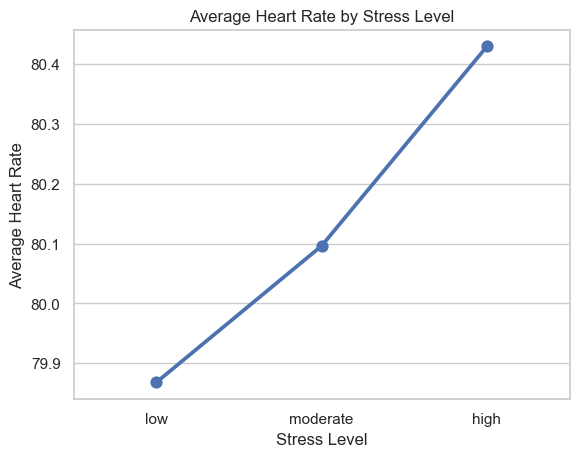

In [29]:
sns.pointplot(
    x='StressLevel',
    y='HeartRate',
    data=df,
    order=['low', 'moderate', 'high'],
    errorbar=None
)

plt.title('Average Heart Rate by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Average Heart Rate')
plt.show()

Average heart rate increases slightly from low to high stress levels, but the differences are very small. No clear relationship between stress level and heart rate is visible in this dataset.

In [30]:
# Group patients by age
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 35, 55, float('inf')],
    labels=['Young', 'Middle-aged', 'Senior']
)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,69,Senior
1,32,Young
2,78,Senior
3,38,Middle-aged
4,41,Middle-aged


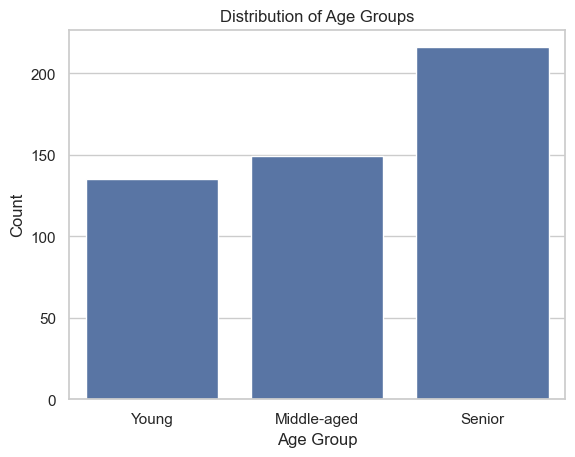

In [31]:
sns.countplot(x='AgeGroup', data=df)

plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

####
**Summary**

This project explored a health monitoring dataset using data cleaning, descriptive statistics, and exploratory data analysis. Missing values were handled, timestamps were converted for time-based analysis, and key health indicators such as heart rate, blood pressure, body temperature, respiratory rate, and oxygen saturation were examined. The analysis showed mostly weak correlations between the numerical health metrics and only small differences across several demographic and lifestyle groups.